# 04 — Auxiliary block-risk model and predictability/detectability hypothesis

A small block-level logistic model is trained **only on train images** using cover blocks versus probe-embedded blocks. For a block, detectability risk is the change in detector logit caused by a fixed probe embedding. This model is used for allocation, not as the final independent steganalyzer. Validation data are used to study the relationship between predictability and detector-derived risk.

In [1]:
from pathlib import Path
import math, joblib, pandas as pd, numpy as np, yaml
from rdhlab.io import read_gray
from rdhlab.risk import fit_block_risk_model
from rdhlab.statistics import predictability_detectability_stats, cluster_bootstrap

config=yaml.safe_load(Path('/workspace/config/experiment.yaml').read_text())
manifest=pd.read_csv(config['dataset']['prepared_manifest'])
train=manifest[manifest.split=='train'].reset_index(drop=True)
val=manifest[manifest.split=='validation'].reset_index(drop=True)
r=config['risk_model']; bs=int(r['block_size'])
blocks_per_image=(int(train.width.iloc[0])//bs)*(int(train.height.iloc[0])//bs)
need_images=min(len(train),math.ceil(int(r['max_training_blocks'])/max(1,blocks_per_image)))
print('Training risk model from',need_images,'train images; up to',r['max_training_blocks'],'blocks')
images=[read_gray(p) for p in train.head(need_images).path]
model=fit_block_risk_model(images,bs,float(r['probe_fraction']),int(r['probe_max_bits']),int(config['project']['seed']),int(r['max_training_blocks']))
model_dir=Path('/workspace/results/models'); model_dir.mkdir(parents=True,exist_ok=True)
joblib.dump(model,model_dir/'block_risk.joblib')
print('Saved block risk model')

Training risk model from 3125 train images; up to 50000 blocks
Saved block risk model


In [2]:
rows=[]
for j,row in val.iterrows():
    img=read_gray(row.path)
    for b in model.score_image_blocks(img,str(row.source_id)):
        b['source_id']=str(row.source_id); rows.append(b)
    if (j+1)%100==0: print(f'{j+1}/2000')
block_df=pd.DataFrame(rows)
block_df.to_csv('/workspace/results/models/validation_block_scores.csv',index=False)
stats=predictability_detectability_stats(block_df)
rho_ci=cluster_bootstrap(block_df,'source_id',lambda z: predictability_detectability_stats(z)['spearman_rho'],n_resamples=int(config['statistics']['cluster_bootstrap_resamples']),seed=int(config['project']['seed']))
print(stats)
print('Cluster-bootstrap CI for Spearman rho:',rho_ci)

100/2000
200/2000
300/2000
400/2000
500/2000
600/2000
700/2000
800/2000
900/2000
1000/2000
1100/2000
1200/2000
1300/2000
1400/2000
1500/2000
1600/2000
1700/2000
1800/2000
1900/2000
2000/2000
{'spearman_rho': 0.036444101831184836, 'spearman_p': 6.973286229350503e-11, 'kendall_tau': 0.024248771805407635, 'kendall_p': 7.708901217729628e-11, 'top_predictability_top_risk_fraction': 0.2603424571928509, 'n_blocks': 32000}
Cluster-bootstrap CI for Spearman rho: {'estimate': 0.036444101831184836, 'low': 0.011999427931028336, 'high': 0.05963355258413382, 'n_clusters': 2000}


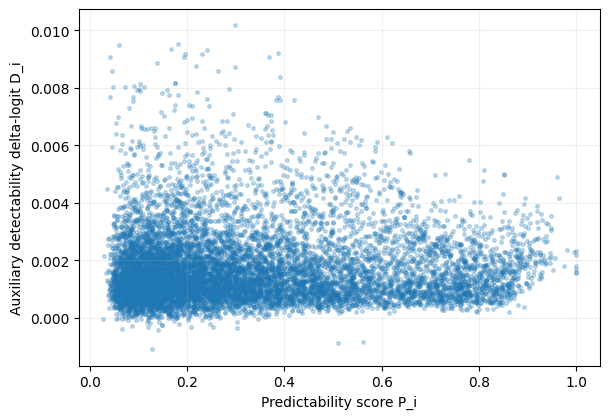

In [3]:
import matplotlib.pyplot as plt
sample=block_df.sample(min(10000,len(block_df)),random_state=int(config['project']['seed']))
fig,ax=plt.subplots(figsize=(6.2,4.3))
ax.scatter(sample.predictability,sample.detectability_risk,s=7,alpha=.25)
ax.set_xlabel('Predictability score P_i'); ax.set_ylabel('Auxiliary detectability delta-logit D_i'); ax.grid(True,alpha=.2)
fig.tight_layout(); fig.savefig('/workspace/results/models/validation_P_vs_D.png',dpi=300); plt.show()

Interpretation is based on **rank association and disagreement**, not on a claim that a finite auxiliary detector proves universal detectability. Final security evidence comes from independent detectors in notebook 07.